# CNN Model Comparison on MNIST

This notebook compares two convolutional models:
- **Model 1** — baseline CNN  trained on 5,000 samples
- **Model 2** — deeper CNN with BatchNorm trained on 500 samples

We compare metrics, confusion matrices, learning curves, convolutional filters, and Grad-CAM visualisations.

### Import Libraries

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({"font.size": 12})

from src.data import load_mnist
from src.model import build_cnn
from src.model2 import build_cnn_v2
from src.train import compile_model, train, evaluate
from src.visualize import (
    plot_training_history,
    plot_sample_predictions,
    plot_confusion_matrix,
    plot_classification_report,
    plot_conv_filters,
    plot_feature_maps,
    plot_gradcam,
)

print("Imports OK")

Imports OK


In [26]:
# Data split and training parameters
SUBSET_M1 = 5000
SUBSET_M2 = 500
EPOCHS_M1 = 20
EPOCHS_M2 = 20
BATCH_M1 = 64
BATCH_M2 = 16
LR = 1e-3

# Data for Model 1
(x_train_m1, y_train_m1), (x_test, y_test) = load_mnist(subset_size=SUBSET_M1)
# Data for Model 2 (smaller subset)
(x_train_m2, y_train_m2), _ = load_mnist(subset_size=SUBSET_M2)

print(f"Model 1 — train: {x_train_m1.shape}, test: {x_test.shape}")
print(f"Model 2 — train: {x_train_m2.shape}, test: {x_test.shape}")

Model 1 — train: (5000, 28, 28, 1), test: (10000, 28, 28, 1)
Model 2 — train: (500, 28, 28, 1), test: (10000, 28, 28, 1)


## Train Model 1 

In [27]:
model1 = build_cnn()
compile_model(model1, learning_rate=LR)
model1.summary()

history1 = train(
    model1, x_train_m1, y_train_m1,
    epochs=EPOCHS_M1, batch_size=BATCH_M1,
    early_stopping_patience=5,
)

Model: "mnist_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7780 - loss: 0.7639 - val_accuracy: 0.9120 - val_loss: 0.3109 - learning_rate: 0.0010
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9429 - loss: 0.1921 - val_accuracy: 0.9380 - val_loss: 0.2013 - learning_rate: 0.0010
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9642 - loss: 0.1230 - val_accuracy: 0.9460 - val_loss: 0.1757 - learning_rate: 0.0010
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9749 - loss: 0.0871 - val_accuracy: 0.9580 - val_loss: 0.1350 - learning_rate: 0.0010
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9816 - loss: 0.0610 - val_accuracy: 0.9640 - val_loss: 0.1152 - learning_rate: 0.0010
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9813 - loss: 0.0607 - val_accuracy: 0.9620 - val_loss: 0.1360 - learning_rate: 0.0010
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9860 - loss: 0.0430 - val_accuracy: 

## Train Model 2 

In [28]:
model2 = build_cnn_v2()
compile_model(model2, learning_rate=LR)
model2.summary()

history2 = train(
    model2, x_train_m2, y_train_m2,
    epochs=EPOCHS_M2, batch_size=BATCH_M2,
    early_stopping_patience=15,
)

Model: "mnist_cnn_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 28, 28, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 14, 14, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 7, 7, 64)       │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_dense (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131,530 (513.79 KB)

 Trainable params: 131,210 (512.54 KB)

 Non-trainable params: 320 (1.25 KB)

Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5378 - loss: 1.6896 - val_accuracy: 0.1800 - val_loss: 2.1801 - learning_rate: 0.0010
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8978 - loss: 0.3827 - val_accuracy: 0.1800 - val_loss: 2.2102 - learning_rate: 0.0010
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9600 - loss: 0.1502 - val_accuracy: 0.1800 - val_loss: 2.2521 - learning_rate: 0.0010
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9511 - loss: 0.1237 - val_accuracy: 0.1800 - val_loss: 2.2706 - learning_rate: 0.0010
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9911 - loss: 0.0384 - val_accuracy: 0.1800 - val_loss: 2.2622 - learning_rate: 5.0000e-04
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9933 - loss: 0.0342 - val_accuracy: 0.1800 - val_loss: 2.2533 - learning_rate: 5.0000e-04
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9867 - loss: 0.0630 - val_a

## Evaluation and Metrics Comparison



In [ ]:
pip install scikit-learn seaborn pandas

In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

metrics1 = evaluate(model1, x_test, y_test)
metrics2 = evaluate(model2, x_test, y_test)

y_pred1 = np.argmax(model1.predict(x_test, verbose=0), axis=1)
y_pred2 = np.argmax(model2.predict(x_test, verbose=0), axis=1)

comparison = pd.DataFrame({
    "Metric": ["Loss", "Accuracy", "Precision (macro)", "Recall (macro)", "F1-score (macro)"],
    "Model 1 (5,000)": [
        f"{metrics1['loss']:.4f}",
        f"{accuracy_score(y_test, y_pred1):.4f}",
        f"{precision_score(y_test, y_pred1, average='macro', zero_division=0):.4f}",
        f"{recall_score(y_test, y_pred1, average='macro', zero_division=0):.4f}",
        f"{f1_score(y_test, y_pred1, average='macro', zero_division=0):.4f}",
    ],
    "Model 2 (500)": [
        f"{metrics2['loss']:.4f}",
        f"{accuracy_score(y_test, y_pred2):.4f}",
        f"{precision_score(y_test, y_pred2, average='macro', zero_division=0):.4f}",
        f"{recall_score(y_test, y_pred2, average='macro', zero_division=0):.4f}",
        f"{f1_score(y_test, y_pred2, average='macro', zero_division=0):.4f}",
    ],
})
print("Metrics Comparison")
comparison


Metrics Comparison


,Metric,"Model 1 (5,000)",Model 2 (500)
0,Loss,0.0857,0.3058
1,Accuracy,0.9744,0.9021
2,Precision (macro),0.9746,0.9092
3,Recall (macro),0.9742,0.9002
4,F1-score (macro),0.9743,0.9012


## Metrics Comparison 

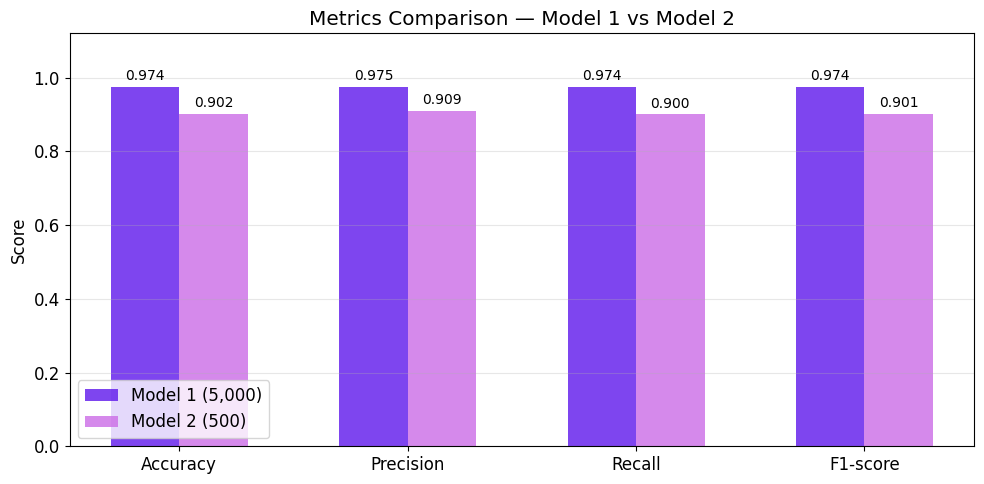

In [31]:
metric_names = ["Accuracy", "Precision", "Recall", "F1-score"]
scores_m1 = [
    accuracy_score(y_test, y_pred1),
    precision_score(y_test, y_pred1, average="macro", zero_division=0),
    recall_score(y_test, y_pred1, average="macro", zero_division=0),
    f1_score(y_test, y_pred1, average="macro", zero_division=0),
]
scores_m2 = [
    accuracy_score(y_test, y_pred2),
    precision_score(y_test, y_pred2, average="macro", zero_division=0),
    recall_score(y_test, y_pred2, average="macro", zero_division=0),
    f1_score(y_test, y_pred2, average="macro", zero_division=0),
]

x = np.arange(len(metric_names))
width = 0.3

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width / 2, scores_m1, width, label="Model 1 (5,000)", color="#5e17eb", alpha=0.8)
bars2 = ax.bar(x + width / 2, scores_m2, width, label="Model 2 (500)", color="#cb6ce6", alpha=0.8)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score")
ax.set_title("Metrics Comparison — Model 1 vs Model 2")
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

## Loss and Accuracy

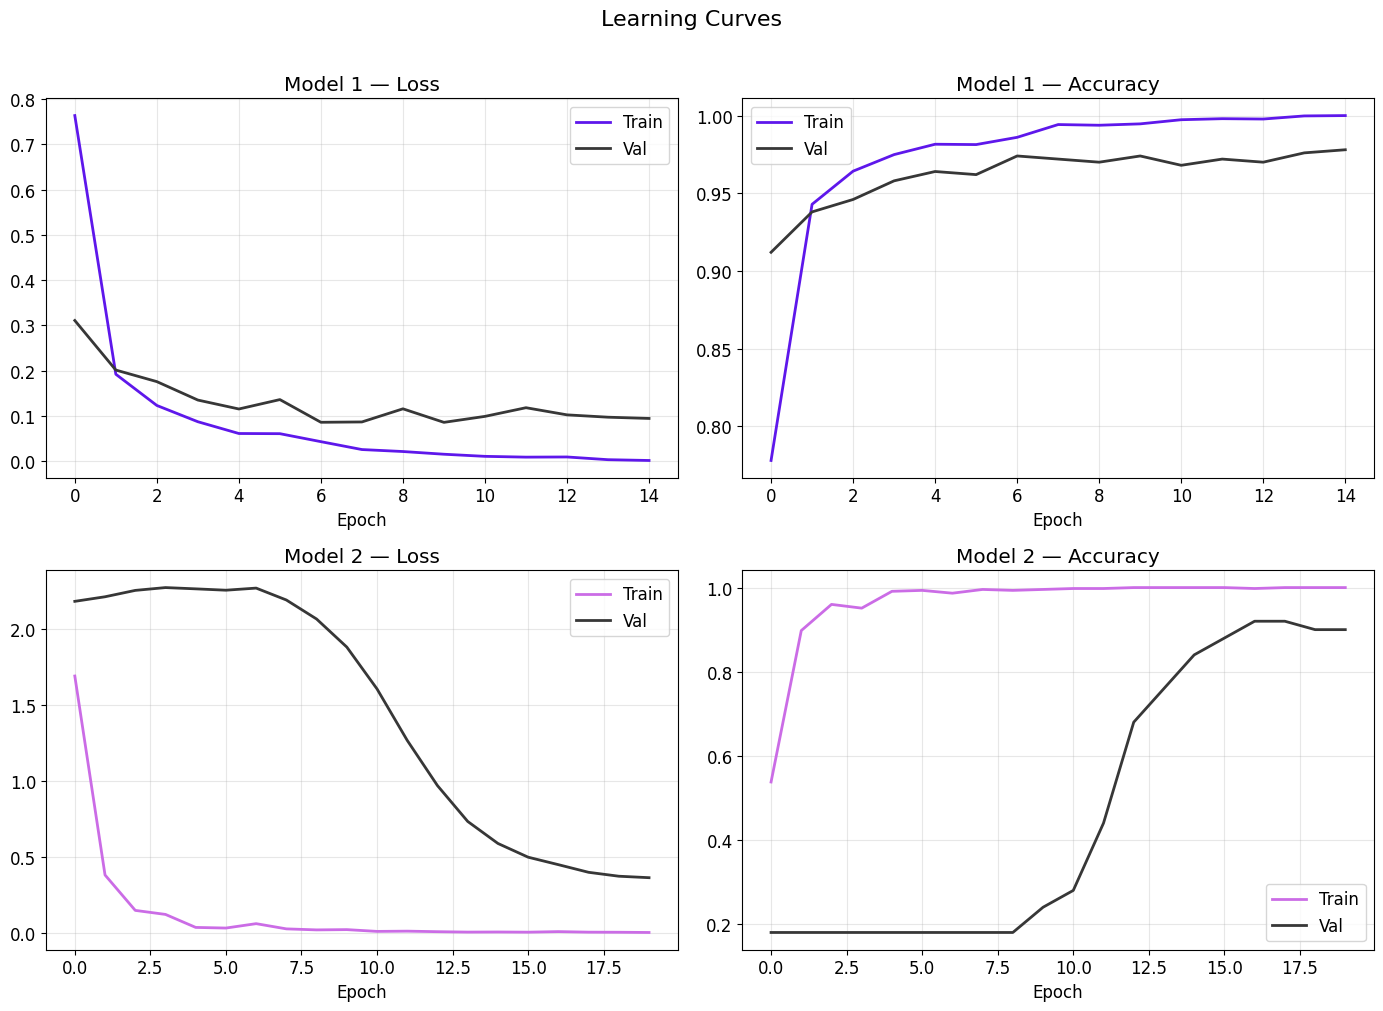

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

h1 = history1.history
h2 = history2.history

# Model 1 — Loss
axes[0, 0].plot(h1["loss"], label="Train", color="#5e17eb", linewidth=2)
axes[0, 0].plot(h1["val_loss"], label="Val", color="#373737", linewidth=2)
axes[0, 0].set_title("Model 1 — Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Model 1 — Accuracy
axes[0, 1].plot(h1["accuracy"], label="Train", color="#5e17eb", linewidth=2)
axes[0, 1].plot(h1["val_accuracy"], label="Val", color="#373737", linewidth=2)
axes[0, 1].set_title("Model 1 — Accuracy")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Model 2 — Loss
axes[1, 0].plot(h2["loss"], label="Train", color="#cb6ce6", linewidth=2)
axes[1, 0].plot(h2["val_loss"], label="Val", color="#373737", linewidth=2)
axes[1, 0].set_title("Model 2 — Loss")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Model 2 — Accuracy
axes[1, 1].plot(h2["accuracy"], label="Train", color="#cb6ce6", linewidth=2)
axes[1, 1].plot(h2["val_accuracy"], label="Val", color="#373737", linewidth=2)
axes[1, 1].set_title("Model 2 — Accuracy")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

fig.suptitle("Learning Curves", fontsize=16, y=1.01)
fig.tight_layout()
plt.show()

## Confusion Matrices

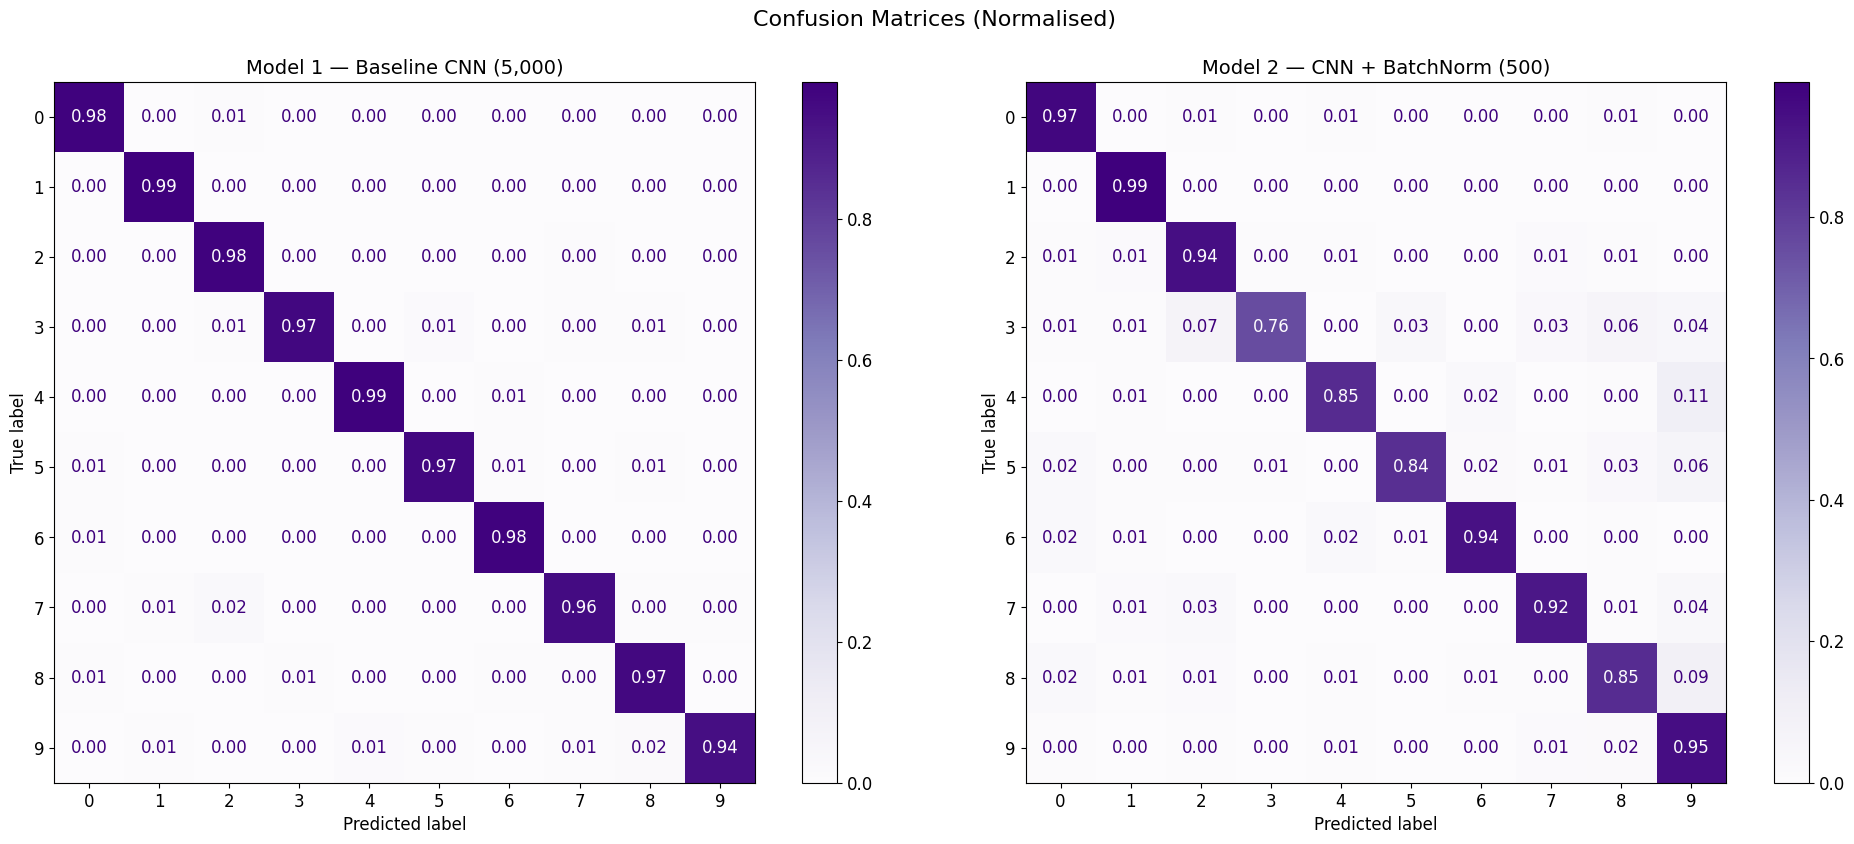

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

cm1 = confusion_matrix(y_test, y_pred1, normalize="true")
cm2 = confusion_matrix(y_test, y_pred2, normalize="true")

disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=list(range(10)))
disp1.plot(cmap="Purples", ax=ax1, values_format=".2f")
ax1.set_title("Model 1 — Baseline CNN (5,000)", fontsize=14)

disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=list(range(10)))
disp2.plot(cmap="Purples", ax=ax2, values_format=".2f")
ax2.set_title("Model 2 — CNN + BatchNorm (500)", fontsize=14)

fig.suptitle("Confusion Matrices (Normalised)", fontsize=16, y=1.02)
fig.tight_layout()
plt.show()

## Per-Class F1-Score

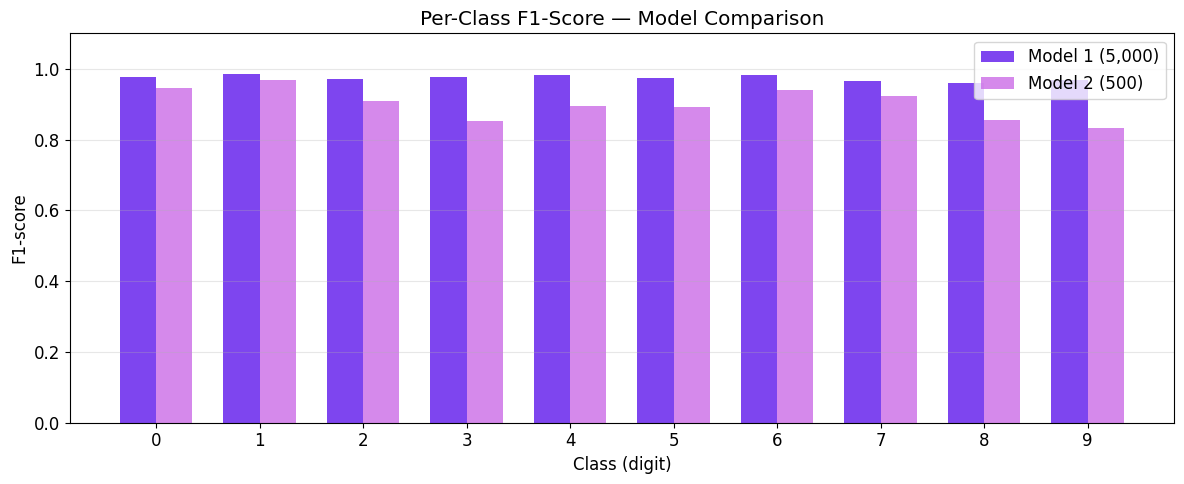

In [34]:
from sklearn.metrics import classification_report

classes = [str(i) for i in range(10)]
report1 = classification_report(y_test, y_pred1, target_names=classes, output_dict=True, zero_division=0)
report2 = classification_report(y_test, y_pred2, target_names=classes, output_dict=True, zero_division=0)

f1_m1 = [report1[c]["f1-score"] for c in classes]
f1_m2 = [report2[c]["f1-score"] for c in classes]

x = np.arange(10)
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width / 2, f1_m1, width, label="Model 1 (5,000)", color="#5e17eb", alpha=0.8)
ax.bar(x + width / 2, f1_m2, width, label="Model 2 (500)", color="#cb6ce6", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_xlabel("Class (digit)")
ax.set_ylabel("F1-score")
ax.set_title("Per-Class F1-Score — Model Comparison")
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

## Convolutional Filters for conv1 Layer

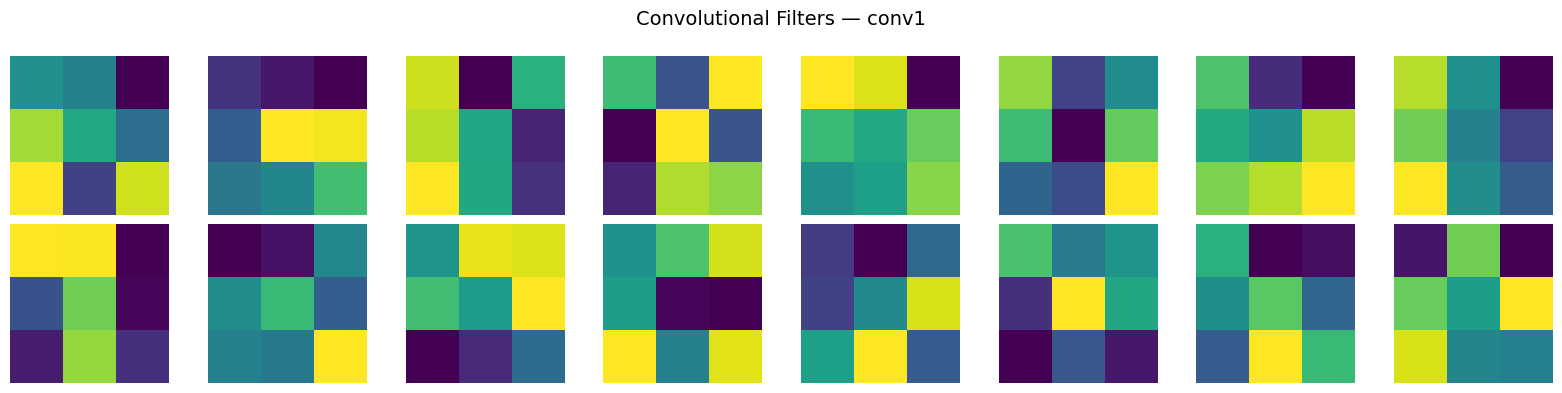

In [35]:
fig, axes = plt.subplots(2, 8, figsize=(16, 4))

for row, (model, name) in enumerate([(model1, "Model 1"), (model2, "Model 2")]):
    filters, _ = model.get_layer("conv1").get_weights()
    n = min(8, filters.shape[-1])
    for i in range(8):
        if i < n:
            axes[row, i].imshow(filters[:, :, 0, i], cmap="viridis")
        axes[row, i].axis("off")
        if i == 0:
            axes[row, i].set_ylabel(name, fontsize=11)

fig.suptitle("Convolutional Filters — conv1", fontsize=14)
fig.tight_layout()
plt.show()

## Grad-CAM 

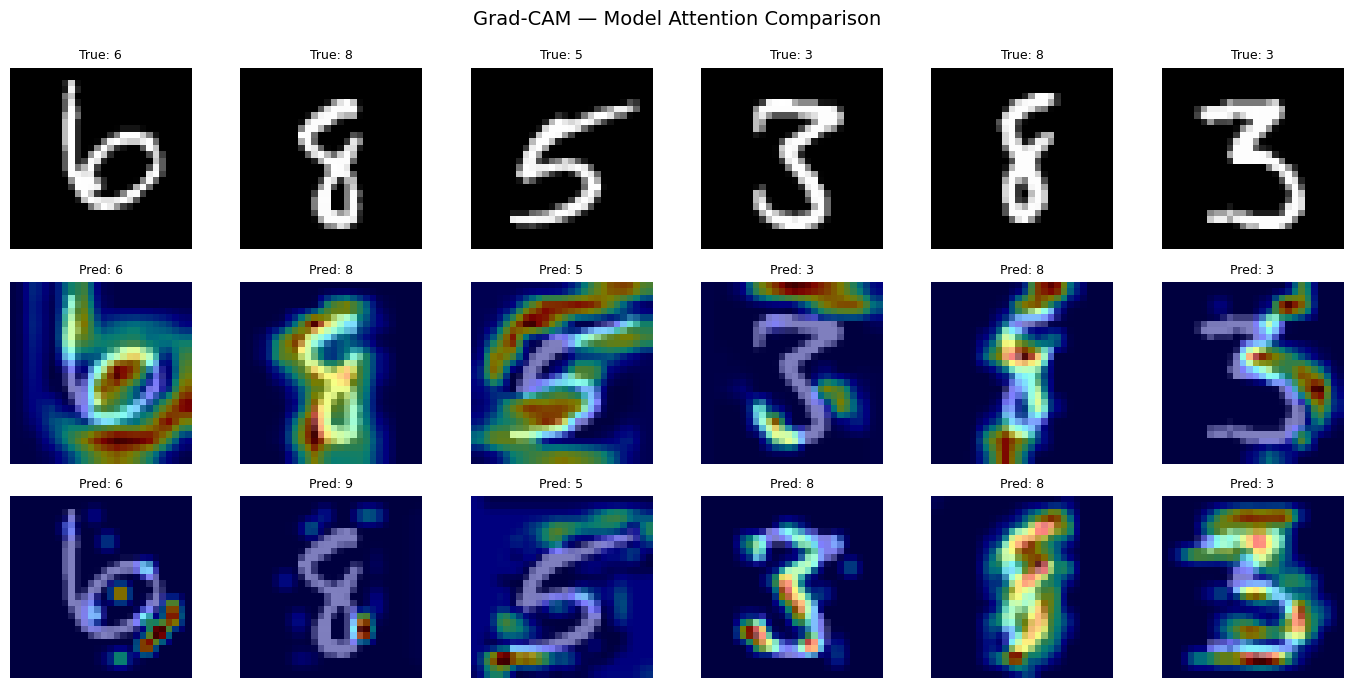

In [36]:
import tensorflow as tf
from src.visualize import compute_gradcam

np.random.seed(7)
idx = np.random.choice(len(x_test), 6, replace=False)

fig, axes = plt.subplots(3, 6, figsize=(14, 7))

for i, ix in enumerate(idx):
    img = x_test[ix]

    # Original
    axes[0, i].imshow(img.squeeze(), cmap="gray")
    axes[0, i].set_title(f"True: {y_test[ix]}", fontsize=9)
    axes[0, i].axis("off")

    # Model 1 Grad-CAM
    cam1 = compute_gradcam(model1, img, layer_name="conv2")
    cam1_r = tf.image.resize(cam1[..., np.newaxis], (28, 28)).numpy().squeeze()
    axes[1, i].imshow(img.squeeze(), cmap="gray")
    axes[1, i].imshow(cam1_r, cmap="jet", alpha=0.5)
    p1 = int(np.argmax(model1.predict(img[np.newaxis], verbose=0)))
    axes[1, i].set_title(f"Pred: {p1}", fontsize=9)
    axes[1, i].axis("off")

    # Model 2 Grad-CAM
    cam2 = compute_gradcam(model2, img, layer_name="conv2")
    cam2_r = tf.image.resize(cam2[..., np.newaxis], (28, 28)).numpy().squeeze()
    axes[2, i].imshow(img.squeeze(), cmap="gray")
    axes[2, i].imshow(cam2_r, cmap="jet", alpha=0.5)
    p2 = int(np.argmax(model2.predict(img[np.newaxis], verbose=0)))
    axes[2, i].set_title(f"Pred: {p2}", fontsize=9)
    axes[2, i].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=11)
axes[1, 0].set_ylabel("Model 1", fontsize=11)
axes[2, 0].set_ylabel("Model 2", fontsize=11)
fig.suptitle("Grad-CAM — Model Attention Comparison", fontsize=14)
fig.tight_layout()
plt.show()